In [ ]:
!pip install -q kaggle

!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d wasifmahmood01/custom-waste-classification-dataset


Dataset URL: https://www.kaggle.com/datasets/wasifmahmood01/custom-waste-classification-dataset
License(s): CC-BY-NC-SA-4.0
https://creativecommons.org/licenses/by-nc-sa/4.0/
100% 5.38G/5.39G [01:26<00:00, 238MB/s]
100% 5.39G/5.39G [01:27<00:00, 66.5MB/s]


In [ ]:
!unzip custom-waste-classification-dataset.zip -d data

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
!ls -R

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/wastes/train/",
    image_size=(380, 380),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/wastes/test/",
    image_size=(380, 380),
    batch_size=32
)

Found 9214 files belonging to 9 classes.
Found 2308 files belonging to 9 classes.


In [ ]:
class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Classes: ['E-waste', 'automobile wastes', 'battery waste', 'glass waste', 'light bulbs', 'metal waste', 'organic waste', 'paper waste', 'plastic waste']


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2),
    layers.RandomZoom(0.2),
])

In [ ]:
base_model = tf.keras.applications.EfficientNetB4(
    include_top=False,
    input_shape=(380, 380, 3),
    weights="imagenet"
)

base_model.trainable = False   # Freeze for initial training

inputs = layers.Input(shape=(380, 380, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 12, 12, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │        16,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,689,960 (67.48 MB)

 Trainable params: 16,137 (63.04 KB)

 Non-trainable params: 17,673,823 (67.42 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_effnetb4.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.6012 - loss: 1.2622

288/288 ━━━━━━━━━━━━━━━━━━━━ 220s 689ms/step - accuracy: 0.6016 - loss: 1.2611 - val_accuracy: 0.8380 - val_loss: 0.5562 - learning_rate: 0.0010
Epoch 2/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.7977 - loss: 0.6301

288/288 ━━━━━━━━━━━━━━━━━━━━ 194s 674ms/step - accuracy: 0.7977 - loss: 0.6301 - val_accuracy: 0.8553 - val_loss: 0.4779 - learning_rate: 0.0010
Epoch 3/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8149 - loss: 0.5672

288/288 ━━━━━━━━━━━━━━━━━━━━ 187s 648ms/step - accuracy: 0.8149 - loss: 0.5672 - val_accuracy: 0.8635 - val_loss: 0.4492 - learning_rate: 0.0010
Epoch 4/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8251 - loss: 0.5232

288/288 ━━━━━━━━━━━━━━━━━━━━ 186s 646ms/step - accuracy: 0.8251 - loss: 0.5232 - val_accuracy: 0.8683 - val_loss: 0.4277 - learning_rate: 0.0010
Epoch 5/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.8406 - loss: 0.4862

288/288 ━━━━━━━━━━━━━━━━━━━━ 187s 648ms/step - accuracy: 0.8406 - loss: 0.4863 - val_accuracy: 0.8692 - val_loss: 0.4156 - learning_rate: 0.0010
Epoch 6/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 206s 664ms/step - accuracy: 0.8477 - loss: 0.4688 - val_accuracy: 0.8661 - val_loss: 0.4118 - learning_rate: 0.0010
Epoch 7/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 191s 665ms/step - accuracy: 0.8437 - loss: 0.4762 - val_accuracy: 0.8666 - val_loss: 0.4065 - learning_rate: 0.0010
Epoch 8/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.8467 - loss: 0.4544

288/288 ━━━━━━━━━━━━━━━━━━━━ 188s 650ms/step - accuracy: 0.8467 - loss: 0.4544 - val_accuracy: 0.8705 - val_loss: 0.4019 - learning_rate: 0.0010
Epoch 9/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.8470 - loss: 0.4427

288/288 ━━━━━━━━━━━━━━━━━━━━ 201s 648ms/step - accuracy: 0.8470 - loss: 0.4427 - val_accuracy: 0.8761 - val_loss: 0.3924 - learning_rate: 0.0010
Epoch 10/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8448 - loss: 0.4542

288/288 ━━━━━━━━━━━━━━━━━━━━ 201s 646ms/step - accuracy: 0.8448 - loss: 0.4542 - val_accuracy: 0.8774 - val_loss: 0.3942 - learning_rate: 0.0010
Epoch 11/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 185s 643ms/step - accuracy: 0.8518 - loss: 0.4350 - val_accuracy: 0.8726 - val_loss: 0.3938 - learning_rate: 0.0010
Epoch 12/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 192s 665ms/step - accuracy: 0.8545 - loss: 0.4349 - val_accuracy: 0.8765 - val_loss: 0.3910 - learning_rate: 2.0000e-04
Epoch 13/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 185s 643ms/step - accuracy: 0.8530 - loss: 0.4254 - val_accuracy: 0.8765 - val_loss: 0.3892 - learning_rate: 2.0000e-04
Epoch 14/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 208s 664ms/step - accuracy: 0.8610 - loss: 0.4127 - val_accuracy: 0.8748 - val_loss: 0.3886 - learning_rate: 2.0000e-04


In [ ]:
base_model.trainable = True
for layer in base_model.layers[:350]:  # Freeze first 350 layers → stable
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 296s 906ms/step - accuracy: 0.7518 - loss: 0.7392 - val_accuracy: 0.8570 - val_loss: 0.4724 - learning_rate: 1.0000e-05
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 310s 868ms/step - accuracy: 0.8103 - loss: 0.5691 - val_accuracy: 0.8666 - val_loss: 0.4326 - learning_rate: 1.0000e-05
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 262s 867ms/step - accuracy: 0.8416 - loss: 0.4858 - val_accuracy: 0.8774 - val_loss: 0.4001 - learning_rate: 1.0000e-05
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.8474 - loss: 0.4505

288/288 ━━━━━━━━━━━━━━━━━━━━ 257s 892ms/step - accuracy: 0.8474 - loss: 0.4506 - val_accuracy: 0.8830 - val_loss: 0.3794 - learning_rate: 1.0000e-05
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.8597 - loss: 0.4215

288/288 ━━━━━━━━━━━━━━━━━━━━ 258s 892ms/step - accuracy: 0.8597 - loss: 0.4215 - val_accuracy: 0.8895 - val_loss: 0.3597 - learning_rate: 1.0000e-05
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.8699 - loss: 0.3889

288/288 ━━━━━━━━━━━━━━━━━━━━ 251s 871ms/step - accuracy: 0.8699 - loss: 0.3888 - val_accuracy: 0.8947 - val_loss: 0.3450 - learning_rate: 1.0000e-05
Epoch 7/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.8811 - loss: 0.3618

288/288 ━━━━━━━━━━━━━━━━━━━━ 251s 871ms/step - accuracy: 0.8811 - loss: 0.3618 - val_accuracy: 0.8977 - val_loss: 0.3320 - learning_rate: 1.0000e-05
Epoch 8/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.8888 - loss: 0.3343

288/288 ━━━━━━━━━━━━━━━━━━━━ 251s 872ms/step - accuracy: 0.8887 - loss: 0.3343 - val_accuracy: 0.8982 - val_loss: 0.3229 - learning_rate: 1.0000e-05
Epoch 9/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.8993 - loss: 0.3135

288/288 ━━━━━━━━━━━━━━━━━━━━ 252s 872ms/step - accuracy: 0.8993 - loss: 0.3135 - val_accuracy: 0.9034 - val_loss: 0.3167 - learning_rate: 1.0000e-05
Epoch 10/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.9088 - loss: 0.2800

288/288 ━━━━━━━━━━━━━━━━━━━━ 262s 872ms/step - accuracy: 0.9088 - loss: 0.2800 - val_accuracy: 0.9051 - val_loss: 0.3068 - learning_rate: 1.0000e-05


In [ ]:
model.save("waste_classifier_effnetB4_final.h5")
model = tf.keras.models.load_model("waste_classifier_effnetB4_final.h5")


In [ ]:
class_names = ['E-waste', 'automobile wastes', 'battery waste', 'glass waste',
               'light bulbs', 'metal waste', 'organic waste', 'paper waste', 'plastic waste']

test_loss, test_acc = model.evaluate(val_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


73/73 ━━━━━━━━━━━━━━━━━━━━ 35s 477ms/step - accuracy: 0.9061 - loss: 0.3093
Test Loss: 0.30684801936149597
Test Accuracy: 0.905112624168396


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

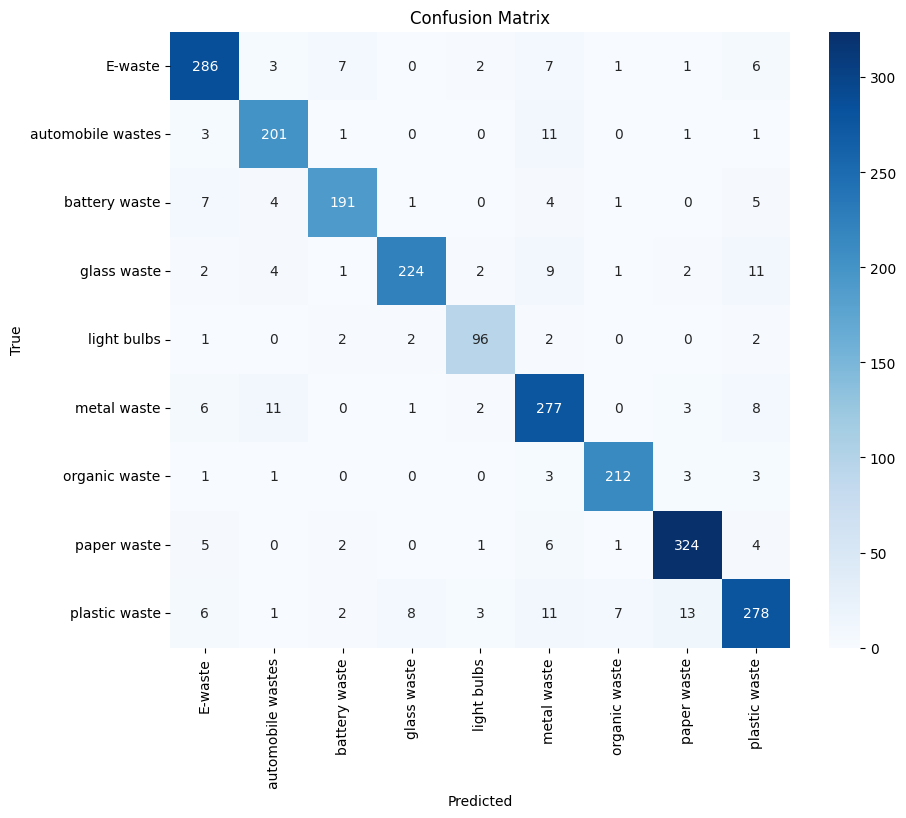

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def predict_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(380, 380))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    print("Predicted Class:", class_names[predicted_class])
    print("Confidence:", confidence)

    plt.imshow(tf.keras.preprocessing.image.load_img(img_path))
    plt.axis("off")
    plt.show()

In [ ]:
model.save("waste_classifier_effnetB4_final.h5")
model = tf.keras.models.load_model("waste_classifier_effnetB4_final.h5")


In [ ]:
model.save("waste_classifier_effnetB4_final.keras")  # use .keras instead of .h5

# --- Loading the model ---
model = tf.keras.models.load_model("waste_classifier_effnetB4_final.keras")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 226 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
from google.colab import files

# Download the file to your local machine
files.download("waste_classifier_effnetB4_final.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>